# One swing-up, five transcriptions: shooting, collocation and pseudospectral in `scaly.mpc`

A cart-pole starts hanging and must be upright and at rest two seconds later, pushed by a bounded
force along a bounded track. The same continuous-time model and running cost go into five
`mpc.OCP`s, one per transcription, and IPOPT solves each. The notebook compares their sizes,
iterations and solutions, checks every solution interval by interval against `solve_ivp`, refines
three of them until they agree to 1e-7, compares the two ways of turning the running cost into a
sum, and writes one controller's control law as C.

| Scaly feature | Where |
| --- | --- |
| `mpc.OCP(ode=..., transcription=...)` with `mpc.TerminalEquality()` and a hard `mpc.Path` | the swing-up problem |
| `si.MultipleShooting(si.rk4, steps=2)` | five transcriptions |
| `si.MultipleShooting(si.implicit, method="radau_iia", stages=2, newton_iters=3)` | five transcriptions |
| `si.Collocation(3)`, `si.Collocation(2, "legendre")` | five transcriptions; refined in refining at the same grid |
| `si.Pseudospectral(4)` | five transcriptions |
| `mpc.MPC(ocp, "ipopt").solve(x0)`, `sc.solver_stats(ctrl.solver)`, `ocp.layout.n_vars`, `ocp.problem.n_eq` | five transcriptions |
| `ocp.interval.state_times`, `control_times`; `scaly.integrators.polynomial.interpolation_matrix` | each solution against `solve_ivp` |
| `cost="points"`, `cost="integral"` | the cost at the points or integrated |
| `write_module(ctrl.law, ...)` | the generated C |

This notebook needs the vendored IPOPT.

In [1]:
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp

sys.path.insert(0, str(Path.cwd().parent / "notebooks"))  # the shared plot style
import plotstyle
import scaly as sc
from scaly import integrators as si
from scaly import mpc
from scaly.codegen import write_module
from scaly.integrators.polynomial import interpolation_matrix

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "mpc" / "nmpc_transcriptions"

## The swing-up problem

The cart-pole is that of `examples/notebooks/nmpc_cartpole.ipynb`: cart position $p$, pole angle
$\theta$ from upright, cart mass $M$, pole mass $m$ at distance $\ell$, force $u$ on the cart,

$$
\ddot p = \frac{u + m \ell \dot\theta^2 \sin\theta - m g \sin\theta\cos\theta}{M + m \sin^2\theta},\qquad
\ddot\theta = \frac{g \sin\theta\,(M + m) - \cos\theta\,(u + m \ell \dot\theta^2 \sin\theta)}{\ell\,(M + m\sin^2\theta)} ,
$$

with the same weights and limits. Over $N = 40$ intervals of $\Delta t = 50$ ms,

$$
\begin{aligned}
\min_{x, u}\ & \Delta t \sum_{k=0}^{N-1} l(x_k, u_k), \qquad l = 2p^2 + 20\,(1 - \cos\theta)^2 + 0.1\,(\dot p^2 + \dot\theta^2) + 0.02\,u^2 \\
\text{s.t.}\ & x_0 = (0, \pi, 0, 0), \quad \dot x = f(x, u), \quad x_N = 0, \quad |u| \le 15, \quad |p_k| \le 1 \ (k < N) .
\end{aligned}
$$

**The terminal equality** `mpc.TerminalEquality()` replaces the terminal cost of `nmpc_cartpole`.
Hanging still with every force zero, the default guess (`ctrl.initial_guess`: every state $x_0$,
every control 0), is a KKT point of the problem with a terminal cost, by symmetry. With a terminal
cost and a guess that breaks the symmetry, IPOPT found swing-ups that end short of upright, and
not the same one for every transcription. $x_N = 0$ makes the default guess infeasible, and from
it every transcription finds the same swing-up.

**The track limit** is a hard `mpc.Path` of the position, which holds at the grid points
$k = 0, \dots, N-1$: the same $N$ inequality rows for every transcription. As a state bound
(`x_bounds`) it would also reach the states that collocation adds inside each interval. More nodes
would then be a tighter problem, not a finer one, and refining a transcription would not bring it
closer to the others.

In [2]:
NX, NU, N, DT = 4, 1, 40, 0.05
M_CART, M_POLE, LENGTH, G = 1.0, 0.3, 0.5, 9.81
U_MAX, P_MAX = 15.0, 1.0
Q = np.array([2.0, 20.0, 0.1, 0.1])  # p, 1 - cos(theta), rates
R = 0.02
X0 = np.array([0.0, np.pi, 0.0, 0.0])


@sc.function(NX, NU, output="xdot", name="transcriptions_cartpole")
def cartpole(x, u):
  theta, pd, td = x[1], x[2], x[3]
  s, c = theta.sin(), theta.cos()
  den = M_CART + M_POLE * s * s
  pdd = (u[0] + M_POLE * LENGTH * td * td * s - M_POLE * G * s * c) / den
  tdd = (G * s * (M_CART + M_POLE) - c * (u[0] + M_POLE * LENGTH * td * td * s)) / (LENGTH * den)
  return sc.stack([pd, td, pdd, tdd])


@sc.function(NX, NU, output="p", name="transcriptions_position")
def position(x, u):
  return x[:1]


@sc.function(NX, NU, output="l", name="transcriptions_stage")
def stage(x, u):
  e = sc.stack([x[0], 1.0 - x[1].cos(), x[2], x[3]])
  return (sc.const(Q) * e * e).sum() + R * u[0] * u[0]


def ocp(key, transcription, cost=None):
  return mpc.OCP(
    ode=cartpole,
    dt=DT,
    horizon=N,
    transcription=transcription,
    stage_cost=stage,
    u_bounds=(-U_MAX, U_MAX),
    constraints=[mpc.Path(position, lo=-P_MAX, hi=P_MAX)],
    terminal=mpc.TerminalEquality(),
    cost=cost,
    name=f"transcriptions_{key}",
  )

## Five transcriptions

A transcription turns one interval $[t_k, t_k + \Delta t]$ into variables and equality residuals.

* **Multiple shooting** keeps the grid states and requires $F(x_k, u_k) - x_{k+1} = 0$, with $F$ a
  discrete map: here two RK4 substeps (order 4), or the two-stage Radau IIA step (order 3), whose
  stage equations $K = f(x_k + \Delta t\,(A \otimes I) K, u_k)$ are solved by three simplified
  Newton iterations inside the map and differentiated by the implicit function theorem. That step
  is the step of Radau collocation of degree 2, with its stages solved inside the map instead of
  by IPOPT.
* **Collocation** of degree $d$ adds the states at $d$ points $\tau_1, \dots, \tau_d$ of the
  interval and requires the polynomial through $x_k$ and them to have the model's derivative at
  each point, the control held. With Radau points $\tau_d = 1$, so the last point's state is
  $x_{k+1}$: $d - 1$ added states and order $2d - 1$. With Gauss (Legendre) points the polynomial's
  value at the end must equal $x_{k+1}$: $d$ added states, $n$ more residuals, order $2d$.
* **Pseudospectral** collocation, each interval one segment of four Radau nodes including $0$,
  puts the states *and the controls* at the nodes. The control moves inside an interval where the
  others hold it, so it solves a slightly different problem, with more freedom.

`mpc.MPC(ocp, "ipopt")` builds the solver; `.solve(x0)` starts from `ctrl.initial_guess(x0)` and
returns an `mpc.Solution`. IPOPT's iterations and its own solve time come from the solver's stats.

In [3]:
IPOPT = {"tol": 1e-10, "max_iter": 500}
TRANSCRIPTIONS = {
  "rk4_x2": ("shooting, RK4 x 2", si.MultipleShooting(si.rk4, steps=2)),
  "radau_iia2": ("shooting, Radau IIA 2", si.MultipleShooting(si.implicit, method="radau_iia", stages=2, newton_iters=3)),
  "radau3": ("collocation, Radau 3", si.Collocation(3)),
  "legendre2": ("collocation, Legendre 2", si.Collocation(2, "legendre")),
  "pseudospectral4": ("pseudospectral, 4 nodes", si.Pseudospectral(4)),
}
runs, solutions, controllers = {}, {}, {}


def solve(key, transcription, cost=None):
  controller = mpc.MPC(ocp(key, transcription, cost), "ipopt", options=IPOPT)
  solution = controller.solve(X0)  # from the default guess
  controllers[key], solutions[key] = controller, solution
  problem = controller.ocp
  runs[key] = {
    "n_vars": problem.layout.n_vars,
    "n_eq": problem.problem.n_eq,
    "n_ineq": problem.problem.n_ineq,
    "status": solution.status.name,
    "iterations": solution.status.iter,
    "solve_time": sc.solver_stats(controller.solver).t_total,
    "cost": solution.cost,
    "terminal": float(np.abs(solution.xs[-1]).max()),
    "u_max": float(np.abs(solution.us).max()),
    "p_max": float(np.abs(solution.xs[:, 0]).max()),
  }


def table(keys, labels):
  print(f"{'transcription':26} {'vars':>5} {'eq':>4} {'ineq':>4} {'iters':>5} {'ms':>6} {'cost':>11} {'|xs - shooting|':>15}")
  for key in keys:
    r = runs[key]
    gap = np.abs(solutions[key].xs - solutions["rk4_x2"].xs).max()
    print(
      f"{labels[key]:26} {r['n_vars']:5d} {r['n_eq']:4d} {r['n_ineq']:4d} {r['iterations']:5d} {1e3 * r['solve_time']:6.1f} {r['cost']:11.6f} {gap:15.1e}"
    )


for key, (_, transcription) in TRANSCRIPTIONS.items():
  solve(key, transcription)
labels = {key: label for key, (label, _) in TRANSCRIPTIONS.items()}
colors = dict(zip(TRANSCRIPTIONS, plotstyle.SERIES, strict=False))
table(TRANSCRIPTIONS, labels)
print(f"statuses {sorted({r['status'] for r in runs.values()})}; every x_N within {max(r['terminal'] for r in runs.values()):.0e} of the origin")

transcription               vars   eq ineq iters     ms        cost |xs - shooting|
shooting, RK4 x 2            204  168   40    69   17.1   53.938387         0.0e+00
shooting, Radau IIA 2        204  168   40    72   30.4   53.950482         4.4e-03
collocation, Radau 3         524  488   40    87   43.3   53.938189         6.1e-05
collocation, Legendre 2      524  488   40    69   28.5   53.938170         1.1e-04
pseudospectral, 4 nodes      804  648   40    52   38.2   51.679078         1.2e-01
statuses ['OK']; every x_N within 1e-29 of the origin


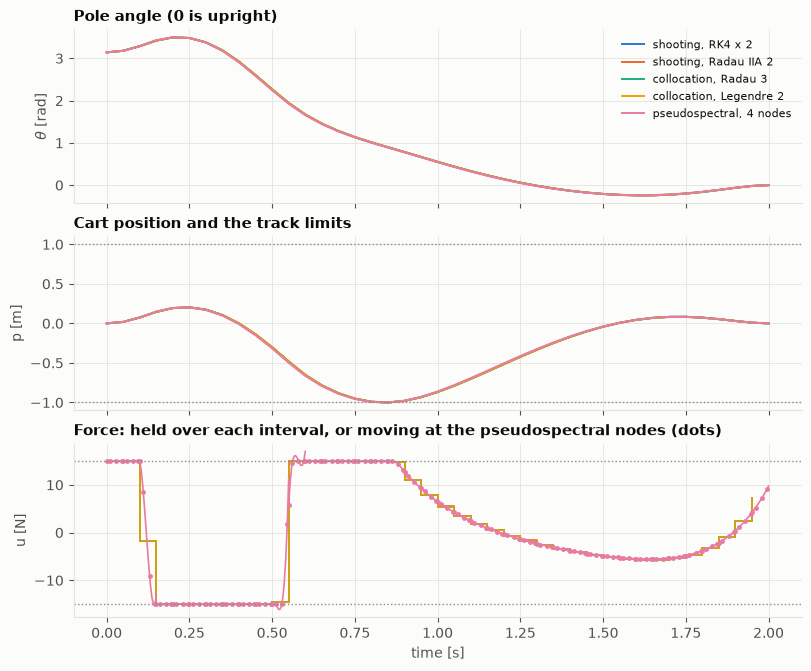

In [4]:
def control_nodes(key, k):
  """The control's nodes in interval k, as fractions of it, and its values there: u_k at 0, then any in zs."""
  interval, solution = controllers[key].ocp.interval, solutions[key]
  inner = [] if solution.zs is None else solution.zs[k, interval.state_times.size * NX :]
  return np.r_[0.0, interval.control_times], np.r_[solution.us[k], inner]


t = DT * np.arange(N + 1)
fig, axes = plt.subplots(3, 1, figsize=(8, 6.6), sharex=True)
for key, label in labels.items():
  xs, us, color = solutions[key].xs, solutions[key].us, colors[key]
  axes[0].plot(t, xs[:, 1], color=color, lw=1.4, label=label)
  axes[1].plot(t, xs[:, 0], color=color, lw=1.4)
  if key == "pseudospectral4":  # the polynomial through the node controls, inside every interval
    tau = np.linspace(0.0, 1.0, 12)
    for k in range(N):
      nodes, values = control_nodes(key, k)
      axes[2].plot(t[k] + DT * tau, interpolation_matrix(nodes, tau) @ values, color=color, lw=1.2)
      axes[2].plot(t[k] + DT * nodes, values, "o", color=color, ms=2.5)
  else:
    axes[2].step(t[:-1], us[:, 0], where="post", color=color, lw=1.2)
axes[0].set_ylabel(r"$\theta$ [rad]")
axes[0].set_title("Pole angle (0 is upright)")
axes[0].legend(loc="upper right", fontsize=8)
for bound in (-P_MAX, P_MAX):
  axes[1].axhline(bound, color=plotstyle.NEUTRAL, lw=1, ls=":")
axes[1].set_ylabel("p [m]")
axes[1].set_title("Cart position and the track limits")
for bound in (-U_MAX, U_MAX):
  axes[2].axhline(bound, color=plotstyle.NEUTRAL, lw=1, ls=":")
axes[2].set_ylabel("u [N]")
axes[2].set_title("Force: held over each interval, or moving at the pseudospectral nodes (dots)")
axes[2].set_xlabel("time [s]")
plt.show()

All five find the same swing-up. The force pushes right for 0.1 s, then left at the bound for
0.45 s, which runs the cart to the left end of the track at 0.85 s, then right at the bound, which
brings the pole over the top in one swing; the rest is a smooth brake to rest at the origin. RK4
shooting and the two collocations lie on top of one another, 1.1e-4 apart at most, and Radau IIA
shooting is 4.4e-3 away. Pseudospectral differs by 0.12, because its force can switch inside an
interval where the others switch at a grid point, at 0.1 s and 0.55 s. Between its nodes the
polynomial through the node forces overshoots the bound near 0.55 s: the bound holds at the
nodes, where the transcription imposes it.

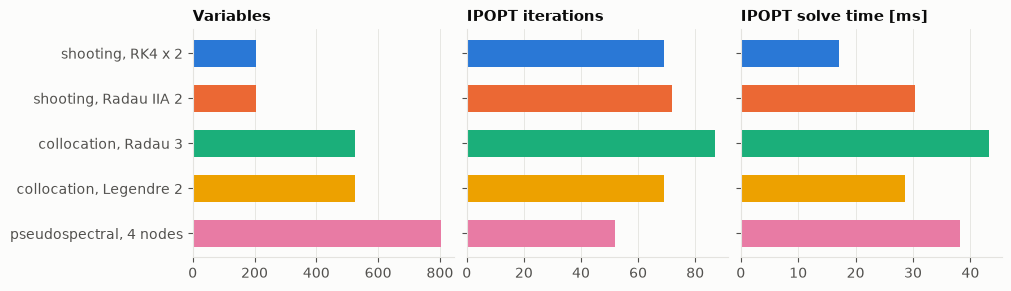

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10, 2.8), sharey=True)
names = [labels[key] for key in TRANSCRIPTIONS]
y = np.arange(len(names))[::-1]
for ax, (field, title, scale) in zip(
  axes, (("n_vars", "Variables", 1), ("iterations", "IPOPT iterations", 1), ("solve_time", "IPOPT solve time [ms]", 1e3)), strict=True
):
  ax.barh(y, [scale * runs[key][field] for key in TRANSCRIPTIONS], color=[colors[key] for key in TRANSCRIPTIONS], height=0.6)
  ax.set_title(title)
  ax.grid(axis="y", visible=False)
axes[0].set_yticks(y, names)
plt.show()

Shooting's variables are the grid states and the forces, 204, and its 168 equalities the initial
state, four residuals per interval and the terminal state. Radau collocation of degree 3 and
Legendre of degree 2 each add two states per interval, 524 variables and 488 equalities: Radau
has three collocation conditions per interval, Legendre two and the end-point condition.
Pseudospectral adds three states and three forces per interval, 804 variables. From the same
default guess IPOPT needs 52 to 87 iterations. Its time grows with the size: RK4 shooting is the
fastest, under 20 ms, and Radau collocation and pseudospectral take about 40 ms. Radau IIA
shooting, as small as RK4 shooting, takes about 30 ms: its map runs Newton iterations and implicit
derivatives in every evaluation.

## Each solution against `solve_ivp`

A transcription is only as good as its integration of the model. Over every interval, `solve_ivp`
(DOP853, tolerances 1e-12) integrates the model from the solution's own state $x_k$ under the
solution's own control, held for the first four, and for pseudospectral the polynomial through the
node controls (`interpolation_matrix` on the nodes $0$ and `ocp.interval.control_times`). The end
must match $x_{k+1}$; the largest mismatch over the horizon is the transcription's integration
error. The same integration carries $\int l\,dt$ as a fifth state, the cost the transcription
approximates.

In [6]:
def flow(x, control, t_eval=None):
  """x(t) and the integral of l from x under u = control(t), over one interval, by solve_ivp."""

  def rhs(t, y):
    theta, pd, td = y[1:4]
    u = control(t)
    s, c = np.sin(theta), np.cos(theta)
    den = M_CART + M_POLE * s * s
    pdd = (u + M_POLE * LENGTH * td**2 * s - M_POLE * G * s * c) / den
    tdd = (G * s * (M_CART + M_POLE) - c * (u + M_POLE * LENGTH * td**2 * s)) / (LENGTH * den)
    e = np.array([y[0], 1.0 - c, pd, td])
    return np.array([pd, td, pdd, tdd, Q @ e**2 + R * u**2])

  return solve_ivp(rhs, (0.0, DT), np.r_[x, 0.0], method="DOP853", rtol=1e-12, atol=1e-12, t_eval=t_eval)


def interval_control(key, k):
  nodes, values = control_nodes(key, k)
  return lambda t: float(interpolation_matrix(nodes, np.array([t / DT]))[0] @ values)


def check(key):
  solution, errors, total = solutions[key], [], 0.0
  for k in range(N):
    end = flow(solution.xs[k], interval_control(key, k)).y[:, -1]
    errors.append(float(np.abs(end[:NX] - solution.xs[k + 1]).max()))
    total += float(end[NX])
  runs[key]["interval_error"], runs[key]["true_cost"] = max(errors), total
  return np.array(errors)


interval_errors = {key: check(key) for key in TRANSCRIPTIONS}
print(f"{'transcription':26} {'vs solve_ivp':>12} {'cost':>11} {'integral of l':>14}")
for key in TRANSCRIPTIONS:
  print(f"{labels[key]:26} {runs[key]['interval_error']:12.1e} {runs[key]['cost']:11.6f} {runs[key]['true_cost']:14.6f}")

transcription              vs solve_ivp        cost  integral of l
shooting, RK4 x 2               1.4e-05   53.938387      51.917038
shooting, Radau IIA 2           1.2e-03   53.950482      51.929012
collocation, Radau 3            1.6e-05   53.938189      51.916848
collocation, Legendre 2         8.6e-05   53.938170      51.916826
pseudospectral, 4 nodes         6.1e-06   51.679078      51.679083


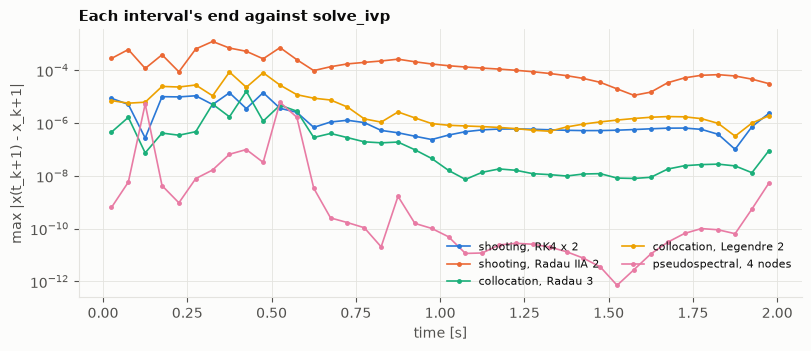

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.4))
for key, label in labels.items():
  ax.semilogy(t[:-1] + DT / 2, interval_errors[key], "o-", ms=2.5, lw=1.2, color=colors[key], label=label)
ax.set_xlabel("time [s]")
ax.set_ylabel("max |x(t_k+1) - x_k+1|")
ax.set_title("Each interval's end against solve_ivp")
ax.legend(loc="lower right", fontsize=8, ncol=2)
plt.show()

RK4 with two substeps and Radau collocation of degree 3 are good to 1.4e-5 and 1.6e-5 over an
interval, Legendre of degree 2 to 8.6e-5, and Radau IIA to 1.2e-3: order 3 over 50 ms, where RK4
takes two 25 ms substeps of order 4. The errors are largest in the first 0.6 s, where the force
switches and the pole swings fastest. Pseudospectral's is 6.1e-6 at most, at the two switches,
which a polynomial force cannot follow, and far smaller where the force is smooth. Two
transcriptions' trajectories differ by a few times the sum of their integration errors: 6.1e-5
between RK4 shooting and Radau collocation.

## Refining at the same grid

The four transcriptions with a held control solve the same problem up to their integration errors,
so refining each inside the interval, on the same grid, should bring them together: RK4 with eight
substeps instead of two (more than `si.UNROLL_STEPS`, so the substeps run as a `scan`), Radau
collocation of degree 5 instead of 3, Legendre of degree 4 instead of 2. The spread is the largest
difference between two of the three trajectories.

In [8]:
REFINED = {
  "rk4_x8": ("shooting, RK4 x 8", si.MultipleShooting(si.rk4, steps=8)),
  "radau5": ("collocation, Radau 5", si.Collocation(5)),
  "legendre4": ("collocation, Legendre 4", si.Collocation(4, "legendre")),
}
COARSE = ("rk4_x2", "radau3", "legendre2")
for key, (label, transcription) in REFINED.items():
  solve(key, transcription)
  labels[key] = label
  interval_errors[key] = check(key)


def spread(keys):
  pairs = list(combinations(keys, 2))
  states = max(float(np.abs(solutions[a].xs - solutions[b].xs).max()) for a, b in pairs)
  return states, max(abs(solutions[a].cost - solutions[b].cost) for a, b in pairs)


(spread_coarse, cost_spread_coarse), (spread_refined, cost_spread_refined) = spread(COARSE), spread(tuple(REFINED))
table(REFINED, labels)
for key in REFINED:
  print(f"{labels[key]:26} against solve_ivp {runs[key]['interval_error']:.1e}")
print(
  f"spread of the three: {spread_coarse:.1e} in the states and {cost_spread_coarse:.1e} in cost; refined {spread_refined:.1e} and {cost_spread_refined:.1e}"
)

transcription               vars   eq ineq iters     ms        cost |xs - shooting|
shooting, RK4 x 8            204  168   40    74   38.5   53.938162         7.1e-05
collocation, Radau 5         844  808   40    98  146.6   53.938162         7.1e-05
collocation, Legendre 4      844  808   40    78  101.1   53.938162         7.1e-05
shooting, RK4 x 8          against solve_ivp 6.2e-08
collocation, Radau 5       against solve_ivp 6.7e-10
collocation, Legendre 4    against solve_ivp 2.7e-09
spread of the three: 1.1e-04 in the states and 2.2e-04 in cost; refined 2.5e-07 and 7.7e-07


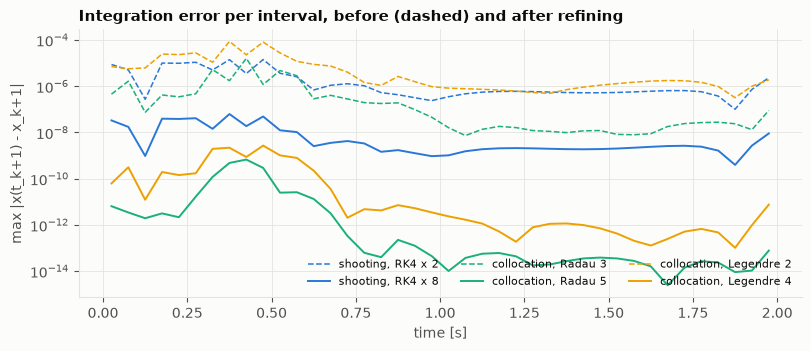

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.4))
for coarse, fine in zip(COARSE, REFINED, strict=True):
  ax.semilogy(t[:-1] + DT / 2, interval_errors[coarse], "--", lw=1.1, color=colors[coarse], label=labels[coarse])
  ax.semilogy(t[:-1] + DT / 2, interval_errors[fine], "-", lw=1.4, color=colors[coarse], label=labels[fine])
ax.set_xlabel("time [s]")
ax.set_ylabel("max |x(t_k+1) - x_k+1|")
ax.set_title("Integration error per interval, before (dashed) and after refining")
ax.legend(loc="lower right", fontsize=8, ncol=3)
plt.show()

Refined, the three are good to 6.2e-8 (RK4 x 8), 2.7e-9 (Legendre 4) and 6.7e-10 (Radau 5) over
an interval. Their trajectories agree to 2.5e-7 instead of 1.1e-4, and their optimal costs to
7.7e-7 instead of 2.2e-4, all at 53.938162: they converge to one problem, the exact model with the
force held. Pseudospectral solves another, with the force moving inside an interval, and is not
part of this comparison.

## The cost at the points or integrated

A continuous-time OCP's running cost $\int_0^T l\,dt$ becomes a sum in one of two ways.
`cost="points"`, the default for a held control, is
$\Delta t \sum_{k<N} l(x_k, u_k)$: the left rectangle rule, first order in $\Delta t$.
`cost="integral"` integrates $l$ over each interval with the transcription's own method, for
shooting as a fifth state carried through the same RK4 substeps. It is the default for
pseudospectral, whose controls inside an interval the points would leave out of the cost. The same
RK4 shooting OCP with `cost="integral"`, against $\int l\,dt$ along the `solve_ivp` flows:

In [10]:
solve("rk4_x2_integral", TRANSCRIPTIONS["rk4_x2"][1], cost="integral")
labels["rk4_x2_integral"] = "shooting, RK4 x 2, integral"
interval_errors["rk4_x2_integral"] = check("rk4_x2_integral")
points_vs_integral_gap = float(np.abs(solutions["rk4_x2"].us - solutions["rk4_x2_integral"].us).max())
print(f"{'cost rule':10} {'optimal cost':>13} {'integral of l':>14} {'difference':>11}")
for rule, key in (("points", "rk4_x2"), ("integral", "rk4_x2_integral")):
  print(f"{rule:10} {runs[key]['cost']:13.6f} {runs[key]['true_cost']:14.6f} {runs[key]['cost'] - runs[key]['true_cost']:+11.1e}")
print(f"the two optimal force profiles differ by up to {points_vs_integral_gap:.3f} N")
print(f"pseudospectral (integral): {runs['pseudospectral4']['cost']:.6f}")

cost rule   optimal cost  integral of l  difference
points         53.938387      51.917038    +2.0e+00
integral       51.917027      51.917038    -1.1e-05
the two optimal force profiles differ by up to 0.011 N
pseudospectral (integral): 51.679078


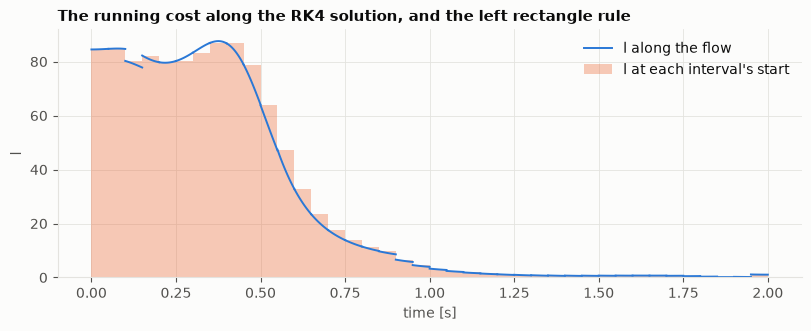

In [11]:
key, tau = "rk4_x2", np.linspace(0.0, DT, 11)
solution = solutions[key]
fig, ax = plt.subplots(figsize=(8, 3.2))


def running_cost(xs, u):
  e = np.stack([xs[0], 1.0 - np.cos(xs[1]), xs[2], xs[3]])
  return Q @ e**2 + R * u**2


ax.bar(
  t[:-1],
  running_cost(solution.xs[:-1].T, solution.us[:, 0]),
  width=DT,
  align="edge",
  color=plotstyle.ORANGE,
  alpha=0.35,
  label="l at each interval's start",
)
for k in range(N):
  run = flow(solution.xs[k], interval_control(key, k), tau)
  ax.plot(t[k] + run.t, running_cost(run.y, solution.us[k, 0]), color=plotstyle.BLUE, lw=1.4, label="l along the flow" if k == 0 else None)
ax.set_xlabel("time [s]")
ax.set_ylabel("l")
ax.set_title("The running cost along the RK4 solution, and the left rectangle rule")
ax.legend(loc="upper right")
plt.show()

The two rules find almost the same trajectory: the forces differ by 0.011 N at most. Their
optimal costs differ by 2.0, 3.9%. Against the integral of $l$ along the flows the points rule's
cost is off by +2.0, the integral rule's by -1.1e-5, RK4's own error. The picture shows why: $l$
falls from 85 hanging to 0 upright, most of the way between 0.4 and 1 s, and the left rectangle
rule reads each interval at its start. Pseudospectral, whose cost is integrated by default,
reaches 51.679 against 51.917 for the held force: moving the force inside an interval saves 0.45%.

## Checks

In [12]:
sizes = {
  "rk4_x2": (204, 168, 40),
  "radau_iia2": (204, 168, 40),
  "radau3": (524, 488, 40),
  "legendre2": (524, 488, 40),
  "pseudospectral4": (804, 648, 40),
  "rk4_x8": (204, 168, 40),
  "radau5": (844, 808, 40),
  "legendre4": (844, 808, 40),
}
for key, size in sizes.items():
  assert (runs[key]["n_vars"], runs[key]["n_eq"], runs[key]["n_ineq"]) == size, key
interval_bounds = {
  "rk4_x2": 1e-4,
  "radau_iia2": 1e-2,
  "radau3": 2e-4,
  "legendre2": 1e-3,
  "pseudospectral4": 1e-4,
  "rk4_x8": 1e-6,
  "radau5": 1e-8,
  "legendre4": 3e-8,
}
for key, bound in interval_bounds.items():
  assert runs[key]["interval_error"] < bound, key  # each solution against solve_ivp, interval by interval
for key, run in runs.items():
  assert run["status"] == "OK" and run["terminal"] < 1e-8 and run["p_max"] <= 1 + 1e-6, key
assert spread_coarse < 1e-3 and spread_refined < min(3e-6, spread_coarse / 100)
assert cost_spread_refined < 1e-5
points, integral, pseudo = runs["rk4_x2"], runs["rk4_x2_integral"], runs["pseudospectral4"]
assert 1.0 < points["cost"] - points["true_cost"] < 3.0  # the points rule is a left Riemann sum of the cost
assert abs(integral["cost"] - integral["true_cost"]) < 1e-4 and points_vs_integral_gap < 0.1
assert 0.95 * integral["cost"] < pseudo["cost"] < integral["cost"]  # controls that move inside an interval do better
assert abs(pseudo["cost"] - pseudo["true_cost"]) < 1e-4
print(f"{len(sizes) + len(interval_bounds) + len(runs) + 6} checks passed")

31 checks passed


## The generated C

Each controller's `law` is one Function, `law(x0, guess) -> (u, guess_next)`: IPOPT nested in it
with the transcription's oracles, and the warm start's shift in its code. For Radau collocation the
guess holds the two added states of every interval too, and the shift moves them with the rest.

In [13]:
law = controllers["radau3"].law
module = write_module(law, GENERATED)
print(f"{module.source_name}: {len(module.source.splitlines())} lines, {len(module.source) / 1e3:.0f} kB")
print(f"inputs {dict(zip(law.input_names, (e.shape for e in law.inputs), strict=True))}, outputs {law.output_names}")

transcriptions_radau3_law.c: 2187 lines, 368 kB
inputs {'x0': (4,), 'guess': (1576,)}, outputs ('u', 'guess_next')
